 # Three Models for CMS Fraud Detection

## Purpose

This project trains and compares three models after EDA.

- Logistic Regression
- Random Forest
- XGBoost

Workflow:
1. Load the data
2. prepare features
3. split train/validation data
4. train three models
5. compare results
6. evaluate the best model
7. predict test providers
8. save outputs


## 1. Import libraries

In [1]:
#if any packages are missing uncomment the line
# %pip install -q pandas numpy matplotlib scikit-learn xgboost joblib

from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    )
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier

RANDOM_STATE = 42

## 2. Load the EDA output files

In [2]:
train_df =pd.read_csv("train_provider_features.csv")

test_df =pd.read_csv("test_provider_features.csv")
print("Train shape:",train_df.shape)
print("Test shape:",test_df.shape)

train_df.head()

Train shape: (5410, 36)
Test shape: (1353, 34)


,Provider,PotentialFraud,ClaimCount,UniqueBeneficiaries,ReimbursementTotal,ReimbursementMean,ReimbursementMedian,ReimbursementStd,ReimbursementMax,DeductibleTotal,...,UniquePrimaryDiagnoses,UniquePrimaryProcedures,ClaimsPerBeneficiary,ReimbursementPerBeneficiary,ReimbursementPerClaim,DeductibleToReimbursementRatio,PhysicianDiversityRatio,DiagnosisDiversityRatio,ProcedureDiversityRatio,FraudLabel
0,PRV51001,No,25,24,104640,4185.600000,400.0,10796.091144,42000,5340.0,...,23,2,1.041667,4360.000000,4185.600000,0.051032,0.560000,0.920000,0.080000,0
1,PRV51003,Yes,132,117,605670,4588.409091,1750.0,7309.794729,57000,66286.0,...,115,32,1.128205,5176.666667,4588.409091,0.109442,0.333333,0.871212,0.242424,1
2,PRV51004,No,149,138,52170,350.134228,70.0,689.963754,3300,310.0,...,128,0,1.079710,378.043478,350.134228,0.005942,0.255034,0.859060,0.000000,0
3,PRV51005,Yes,1165,495,280910,241.124464,70.0,491.556392,4080,3700.0,...,809,0,2.353535,567.494949,241.124464,0.013171,0.005150,0.694421,0.000000,1
4,PRV51007,No,72,58,33710,468.194444,80.0,1433.769116,10000,3264.0,...,71,1,1.241379,581.206897,468.194444,0.096826,0.138889,0.986111,0.013889,0


## 3. Prepare features and target

In [3]:
if "FraudLabel" in train_df.columns:
    y = train_df["FraudLabel"]
    y = pd.to_numeric(y)
else:
    y = train_df["PotentialFraud"]
    y = y.map({"No": 0,"Yes": 1})

X = train_df.drop(columns=["Provider", "PotentialFraud", "FraudLabel"],errors="ignore")

X_test = test_df.drop(columns=[ "Provider", "PotentialFraud", "FraudLabel"],errors="ignore")

X = X.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

X = X.replace(np.inf, np.nan)
X = X.replace(-np.inf, np.nan)
X = X.fillna(0)

X_test = X_test.replace(np.inf, np.nan)
X_test = X_test.replace(-np.inf, np.nan)
X_test = X_test.fillna(0)

X_test = X_test.reindex(columns=X.columns,fill_value=0)

print("Number of features =", X.shape[1])
print("Fraud rate =", y.mean())

Number of features = 33
Fraud rate = 0.09353049907578559


## 4. Split training and validation data

In [4]:
X_train, X_valid, y_train, y_valid=train_test_split(X,y,test_size=0.25,random_state=RANDOM_STATE,stratify=y,)

print("Training rows:",len(X_train))
print("Validation rows:",len(X_valid))

Training rows: 4057
Validation rows: 1353


## 5. Train Logistic Regression

In [5]:
#logistic Regression works better with scaled features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

logistic_model = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)

logistic_model.fit(X_train_scaled, y_train)

logistic_probability = logistic_model.predict_proba(X_valid_scaled)[:, 1]

## 6. Train Random Forest

In [6]:
random_forest_model=RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

random_forest_model.fit(X_train, y_train)

random_forest_probability = random_forest_model.predict_proba(X_valid)[:, 1]

## 7.Training XGBoost

In [7]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgboost_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

xgboost_model.fit(X_train, y_train)

xgboost_probability = xgboost_model.predict_proba(X_valid)[:, 1]

## 8.Comparing the models


In [8]:
probabilities={
    "Logistic Regression": logistic_probability,
    "Random Forest": random_forest_probability,
    "XGBoost": xgboost_probability,
}

results = []

for name, probability in probabilities.items():
    results.append({
        "Model": name,
        "PR_AUC": average_precision_score(
            y_valid,
            probability,
        ),
        "ROC_AUC": roc_auc_score(
            y_valid,
            probability,
        ),
    })



results_df=(
    pd.DataFrame(results)
    .sort_values("PR_AUC", ascending=False)
    .reset_index(drop=True)
)

results_df

,Model,PR_AUC,ROC_AUC
0,Logistic Regression,0.758922,0.960694
1,XGBoost,0.750630,0.959589
2,Random Forest,0.737419,0.958915


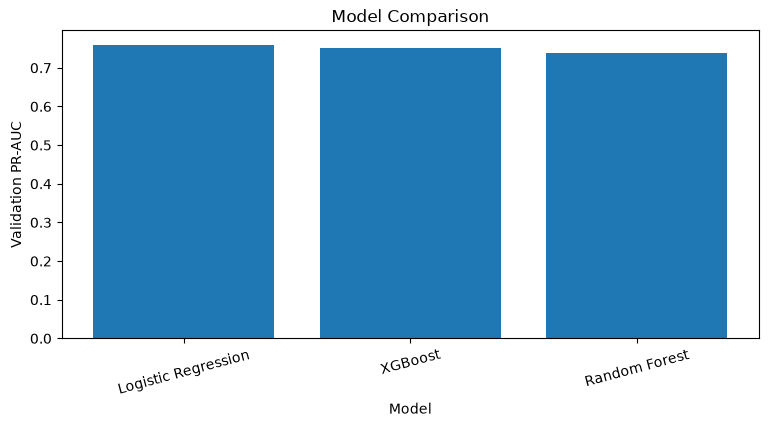

In [9]:
plt.figure(figsize=(9,4))

plt.bar(results_df["Model"],results_df["PR_AUC"],)

plt.title("Model Comparison")
plt.xlabel("Model")
plt.ylabel("Validation PR-AUC")
plt.xticks(rotation=15)
plt.show()

## 9.Evaluating the best model

In [10]:
best_model_name=results_df.loc[0, "Model"]
best_probability = probabilities[best_model_name]

best_prediction=(best_probability >= 0.50).astype(int)

print("Best model:", best_model_name)
print()
print(
    classification_report(
        y_valid,
        best_prediction,
        target_names=["Non-Fraud", "Fraud"],
        digits=4,
    )
)

Best model: Logistic Regression

              precision    recall  f1-score   support

   Non-Fraud     0.9849    0.9029    0.9421      1226
       Fraud     0.4803    0.8661    0.6180       127

    accuracy                         0.8995      1353
   macro avg     0.7326    0.8845    0.7801      1353
weighted avg     0.9375    0.8995    0.9117      1353



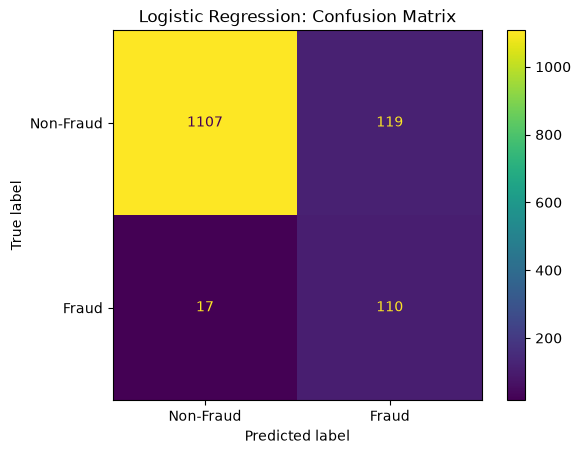

In [11]:
ConfusionMatrixDisplay.from_predictions( y_valid,best_prediction,display_labels=["Non-Fraud","Fraud"],)

plt.title(f"{best_model_name}: Confusion Matrix")
plt.show()

## 10. Showing feature importance

In [12]:
if best_model_name == "Logistic Regression":
    importance = np.abs(logistic_model.coef_[0])
elif best_model_name == "Random Forest":
    importance = random_forest_model.feature_importances_
else:
    importance = xgboost_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance,
}).sort_values("Importance", ascending=False).reset_index(drop=True)

feature_importance.head(15)

,Feature,Importance
0,HospitalStayMax,1.457773
1,ClaimCount,1.151946
2,ReimbursementMedian,1.145669
3,ReimbursementTotal,0.888562
4,UniqueBeneficiaries,0.857860
5,HospitalStayMean,0.807964
6,ReimbursementPerBeneficiary,0.685492
7,DiagnosisCountMean,0.673751
8,ReimbursementPerClaim,0.446083
9,ReimbursementMean,0.446083


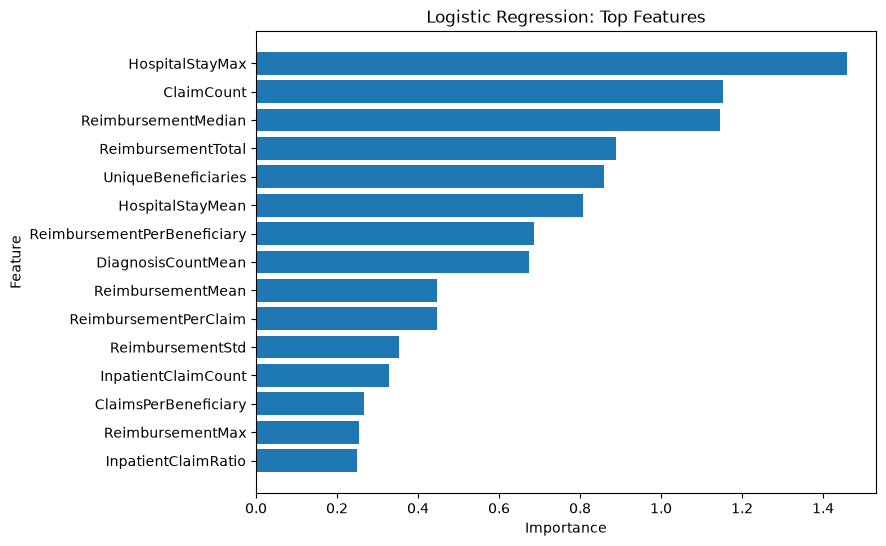

In [13]:
top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(8, 6))

plt.barh(top_features["Feature"], top_features["Importance"])

plt.title(f"{best_model_name}: Top Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Conclusion

This notebook has these modeling steps:

- train three common classification models
- compare PR-AUC and ROC-AUC
- evaluate the best model
- review important features

Disclaimer:    This project is only for educational purposes